**Author**: Felipe Matheus
**Pipeline**: Uncertainty-aware MBC — Annealing with **upstream grain-size propagation**

Downstream counterpart of `mbc_annealing_uncertainty.ipynb`. Same shape — fix
the material state, sweep a dense (temperature, time) grid, chance-constrain,
rank by cost, export — with ONE structural addition: the **grain-size surrogate
is treated as an upstream stage** whose calibrated predictive distribution is
Monte-Carlo-propagated into any downstream surrogate that consumes it
(copper_digital_twin_v4 §4.2).

The propagation is **agnostic**: no target names are hardcoded. After loading
the bundles, `mbc.detect_downstream_consumers` inspects each downstream
bundle's `features` for the upstream target column (`grain_size_final` by
convention). Surrogates that consume it (e.g. the new IACS trained on
initial + final grain size) are propagated with K Monte Carlo trajectories;
surrogates that do not (e.g. the current UTS) are predicted plainly — both
through a single call, `mbc.predict_all_with_propagation`. Everything after
that call (feasibility, cost, selection, export) is IDENTICAL to the
non-propagated notebook, because consumers' `{s}_mu` / `{s}_sigma` already
carry the propagated variance.

Shared-method policy: every step calls `MBCInference` /
`ProbabilisticEvaluation` methods that the standalone script
(`script_mbc_annealing_downstream.py`) also calls — fix a method once, both
entry points are fixed.


# 1. Setup

In [1]:
import os
import sys
import logging
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.modeling.Modeling import Modeling
from src.modeling.MBCInference import MBCInference
from src.metrics.ProbabilisticEvaluation import ProbabilisticEvaluation
from src.DataLoader import LoaderHelper
from config.Variables import Variables

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

%load_ext autoreload
%autoreload 2

modl = Modeling()
load = LoaderHelper()
varv = Variables()
mbc = MBCInference(modl, load)
pev = ProbabilisticEvaluation()

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Configuration

`material_properties` are the FIXED features of the current state (everything the
surrogates need except temperature/time, which are swept). `operational_limits`
and `step` define the grid; `min_setpoints` the targets; `delta` the risk knob.

In production these come from `config/config_script_annealing.yaml`; here they are
inline for clarity. Note the bundle dirs point at the run folders produced by
Section 10 of the annealing notebooks (or any `<run_dir>` from ExperimentRunner).

In [58]:
# ---- TAG folders (best run auto-picked by RMSE, no hard-coded hash) ----
IACS_TAG_DIR = os.path.join(varv.PATHS.models, "annealing_iacs",
                            "with-grain-size")
UTS_TAG_DIR  = os.path.join(varv.PATHS.models, "annealing_uts",
                            "experiments", "annealing-uts-v1-best_quality")
GS_TAG_DIR   = os.path.join(varv.PATHS.models, "annealing_grain_size",
                            "first_test_old_data")

down_bundles = mbc.load_surrogates_best(
    {"iacs": IACS_TAG_DIR, "uts": UTS_TAG_DIR}, metric="rmse",
)
up_bundle = mbc.load_surrogates_best({"gs": GS_TAG_DIR}, metric="rmse")["gs"]

# ---- Fixed material state (features other than temperature/time) ----
# Must contain every non-grid feature each surrogate needs, INCLUDING the
# upstream's own features (grain_size = INITIAL grain size). The consumed
# feature (grain_size_final) is NOT set here — it is filled per Monte Carlo
# sample during propagation.
MATERIAL_PROPERTIES = {
    "purity": 99.95,
    "iacs": 99,
    "grain_size": 200.0,          # initial grain size (upstream feature)
    "initial_diameter": 1.2,
    "tensile_strength": 250.0,
}

# ---- Grid (inclusive of upper bound, like the deterministic build_param_grid) ----
OPERATIONAL_LIMITS = {
    "temperature": [523, 723],   # Kelvin
    "time": [30, 120],           # minutes
}
STEP = {"temperature": 10, "time": 10}

# ---- Probabilistic acceptance ----
MIN_SETPOINTS = {"iacs": 101.5, "tensile_strength": 210.0}   # short_name -> minimum
DELTA = 0.5                                    # keep cells with Pr >= 1 - delta
KAPPA = 1.645                                   # one-sided 95% LCB for risk ranking

# ---- Monte Carlo propagation ----
K_SAMPLES = 200          # upstream trajectories per cell (spec §4.2)
SEED = 0
DOWNSTREAM_FEATURE = None  # None -> defaults to up_bundle.target ("grain_size_final")

# ---- Selection criteria (mirror the deterministic labels) ----
SELECTION_SPEC_LOW = {
    "lowest_time": "time",
    "lowest_temperature": "temperature",
    "lowest_cost": "cost",
    "lowest_cost_phys": "cost_phys",
}
SELECTION_SPEC_HIGH = {
    "safest_iacs": "pr_success_iacs",
    "safest_combined": "pr_success_all",
}


2026-07-17 08:45:07,318 | INFO | src.modeling.MBCInference | Resolved best bundle by rmse: annealing-uts-v1-best_quality__time_limit_a=900__num_bag_folds_a=10__df848c54
2026-07-17 08:45:07,608 | INFO | src.modeling.MBCInference | Loaded surrogate 'iacs' (features=['purity', 'iacs', 'grain_size', 'grain_size_final', 'temperature', 'time']) from ..\..\models\annealing_iacs\with-grain-size
2026-07-17 08:45:07,892 | INFO | src.modeling.MBCInference | Loaded surrogate 'tensile_strength' (features=['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time']) from ..\..\models\annealing_uts\experiments\annealing-uts-v1-best_quality\annealing-uts-v1-best_quality__time_limit_a=900__num_bag_folds_a=10__df848c54
2026-07-17 08:45:08,256 | INFO | src.modeling.MBCInference | Loaded surrogate 'grain_size' (features=['purity', 'grain_size', 'temperature', 'time']) from ..\..\models\annealing_grain_size\first_test_old_data


# 3. Load surrogates

In [59]:
# down_bundles = mbc.load_surrogates(BUNDLE_DIRS)
for key, b in down_bundles.items():
    art = b.artifacts
    print(f"[{key}] target={b.target} | features={b.features}")
    print(f"      recalibration_c={art['recalibration_c']:.4f} | "
          f"y_min={art.get('y_min')} y_max={art.get('y_max')}")

[iacs] target=iacs_final | features=['purity', 'iacs', 'grain_size', 'grain_size_final', 'temperature', 'time']
      recalibration_c=2.0451 | y_min=None y_max=105.0
[uts] target=tensile_strength_final | features=['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time']
      recalibration_c=0.8647 | y_min=0.0 y_max=None


## 3.1 Detect which surrogates consume the upstream target

Purely structural check — a downstream bundle is a consumer iff the upstream
feed column (default: the upstream **target**, `grain_size_final`) appears in
its `features`. Nothing is hardcoded: retrain IACS with or without the grain
size and this cell adapts by itself.


In [60]:
consumers = mbc.detect_downstream_consumers(
    down_bundles, up_bundle, feature_name=DOWNSTREAM_FEATURE,
)
print(f"Upstream: {up_bundle.target} (features: {up_bundle.features})")
print(f"Consumers of the upstream prediction: {list(consumers) or 'NONE'}")
for key, b in down_bundles.items():
    tagm = "-> PROPAGATED" if key in consumers else "-> plain prediction"
    print(f"  {key:6s} features={b.features} {tagm}")


2026-07-17 08:45:08,522 | INFO | src.modeling.MBCInference | Downstream 'iacs' (target=iacs_final) CONSUMES upstream feature 'grain_size_final'.
2026-07-17 08:45:08,523 | INFO | src.modeling.MBCInference | Downstream 'uts' (target=tensile_strength_final) does not consume upstream feature 'grain_size_final'.


Upstream: grain_size_final (features: ['purity', 'grain_size', 'temperature', 'time'])
Consumers of the upstream prediction: ['iacs']
  iacs   features=['purity', 'iacs', 'grain_size', 'grain_size_final', 'temperature', 'time'] -> PROPAGATED
  uts    features=['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time'] -> plain prediction


# 4. Build the (temperature, time) grid

The fixed material state is broadcast across every grid cell. Each surrogate will
later pick only the columns it needs, so IACS (4 features) and UTS (5 features)
share the same frame.

In [61]:
param_grid = mbc.build_param_grid(OPERATIONAL_LIMITS, STEP)
df_grid = mbc.build_state_grid_df(MATERIAL_PROPERTIES, param_grid)

print(f"Grid: {len(param_grid['temperature'])} temperatures x "
      f"{len(param_grid['time'])} times = {len(df_grid)} cells")
df_grid

Grid: 21 temperatures x 10 times = 210 cells


,purity,iacs,grain_size,initial_diameter,tensile_strength,temperature,time
0,99.95,99,200.0,1.2,250.0,523,30
1,99.95,99,200.0,1.2,250.0,523,40
2,99.95,99,200.0,1.2,250.0,523,50
3,99.95,99,200.0,1.2,250.0,523,60
4,99.95,99,200.0,1.2,250.0,523,70
...,...,...,...,...,...,...,...
205,99.95,99,200.0,1.2,250.0,723,80
206,99.95,99,200.0,1.2,250.0,723,90
207,99.95,99,200.0,1.2,250.0,723,100
208,99.95,99,200.0,1.2,250.0,723,110


# 5. Predict — full predictive distribution per cell

`predict_all` runs each surrogate's `predict_with_uncertainty` (epistemic +
aleatoric variance, OOD inflation, scalar recalibration, physical truncation) and
merges the distribution columns. For surrogate `s` you get `s_mu`, `s_sigma`,
`s_sigma2_epist`, `s_sigma2_aleat`, `s_ood_multiplier` (+ truncation columns when
the surrogate has a finite physical bound, e.g. IACS at 105).

In [62]:
# Single agnostic entry point: upstream predicted once; consumers get the
# K-sample Monte Carlo propagation (their sigma INCLUDES the propagated
# upstream variance); non-consumers are predicted plainly, exactly as
# mbc.predict_all would. Same call as in script_mbc_annealing_downstream.py.
df_pred = mbc.predict_all_with_propagation(
    down_bundles, up_bundle, df_grid,
    downstream_feature=DOWNSTREAM_FEATURE,
    k_samples=K_SAMPLES, ood_gamma=1.0, seed=SEED,
)
df_pred.head()


2026-07-17 08:45:08,791 | INFO | src.modeling.MBCInference | Downstream 'iacs' (target=iacs_final) CONSUMES upstream feature 'grain_size_final'.
2026-07-17 08:45:08,792 | INFO | src.modeling.MBCInference | Downstream 'uts' (target=tensile_strength_final) does not consume upstream feature 'grain_size_final'.
2026-07-17 08:45:13,102 | INFO | src.modeling.Modeling | OOD inflation applied to 26/210 rows (max m=2.00).
2026-07-17 08:45:14,204 | INFO | src.modeling.Modeling | OOD inflation applied to 26/210 rows (max m=2.13).
2026-07-17 08:45:14,968 | INFO | src.modeling.Modeling | OOD inflation applied to 20/210 rows (max m=2.75).
2026-07-17 08:45:15,637 | INFO | src.modeling.Modeling | OOD inflation applied to 25/210 rows (max m=2.26).
2026-07-17 08:45:16,323 | INFO | src.modeling.Modeling | OOD inflation applied to 21/210 rows (max m=1.72).
2026-07-17 08:45:17,024 | INFO | src.modeling.Modeling | OOD inflation applied to 20/210 rows (max m=1.42).
2026-07-17 08:45:17,703 | INFO | src.modeli

,purity,iacs,grain_size,initial_diameter,tensile_strength,temperature,time,grain_size_mu,grain_size_sigma,grain_size_sigma2_epist,...,iacs_sigma2_epist,iacs_sigma2_aleat,tensile_strength_mu,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max
0,99.95,99,200.0,1.2,250.0,523,30,457.679499,209.439343,6594.808489,...,2.099811,1.433097,232.148544,18.802371,108.445853,364.319336,1.0,232.148544,18.802371,0.0
1,99.95,99,200.0,1.2,250.0,523,40,424.557393,199.749458,1143.030223,...,1.424631,1.433097,231.124011,19.330748,135.390129,364.319336,1.0,231.124011,19.330748,0.0
2,99.95,99,200.0,1.2,250.0,523,50,402.669714,197.898452,130.979196,...,1.734457,1.433097,232.516513,20.206089,181.670803,364.319336,1.0,232.516513,20.206089,0.0
3,99.95,99,200.0,1.2,250.0,523,60,405.637144,198.538744,479.997813,...,1.617330,1.433097,231.218039,21.453522,251.165626,364.319336,1.0,231.218039,21.453522,0.0
4,99.95,99,200.0,1.2,250.0,523,70,430.196986,202.765249,2812.116460,...,0.864035,1.433097,229.362960,22.971588,341.351706,364.319336,1.0,229.362960,22.971588,0.0


In [63]:
df_pred.columns

Index(['purity', 'iacs', 'grain_size', 'initial_diameter', 'tensile_strength',
       'temperature', 'time', 'grain_size_mu', 'grain_size_sigma',
       'grain_size_sigma2_epist', 'grain_size_sigma2_aleat',
       'grain_size_ood_multiplier', 'grain_size_mu_trunc',
       'grain_size_sigma_trunc', 'grain_size_p_above_max', 'iacs_mu',
       'iacs_sigma', 'iacs_sigma2_propagated', 'iacs_sigma2_epist',
       'iacs_sigma2_aleat', 'tensile_strength_mu', 'tensile_strength_sigma',
       'tensile_strength_sigma2_epist', 'tensile_strength_sigma2_aleat',
       'tensile_strength_ood_multiplier', 'tensile_strength_mu_trunc',
       'tensile_strength_sigma_trunc', 'tensile_strength_p_above_max'],
      dtype='object')

## 5.1 How much of the downstream σ comes from upstream?

For each propagated surrogate, `{s}_sigma2_propagated` is the variance injected
by the upstream grain-size uncertainty (law of total variance across the K
trajectories). Its share of `{s}_sigma²` tells you whether the downstream
uncertainty is dominated by its own model error or by not knowing the grain
size — i.e. whether more grain-size data would tighten the IACS forecast.


In [64]:
prop_cols = [c for c in df_pred.columns if c.endswith("_sigma2_propagated")]
if not prop_cols:
    print("No surrogate was propagated (no consumer of the upstream target).")
else:
    rows = []
    for c in prop_cols:
        s = c.replace("_sigma2_propagated", "")
        share = df_pred[c] / (df_pred[f"{s}_sigma"] ** 2)
        rows.append({
            "surrogate": s,
            "mean share of sigma2 from upstream": float(share.mean()),
            "max share": float(share.max()),
            "mean sigma (total)": float(df_pred[f"{s}_sigma"].mean()),
            "mean sigma (propagated only)": float(np.sqrt(df_pred[c]).mean()),
        })
    display(pd.DataFrame(rows).round(3))


,surrogate,mean share of sigma2 from upstream,max share,mean sigma (total),mean sigma (propagated only)
0,iacs,0.141,0.302,1.747,0.643


# 6. Probabilistic feasibility — Pr(Y >= setpoint)

The deterministic controller kept cells where `pred >= min`. Here we compute, under
the calibrated **truncated** predictive law, the probability each target clears its
setpoint, then gate at `Pr >= 1 - delta`. `pr_success_all` multiplies the per-target
probabilities (independence assumption — conservative and transparent).

In [65]:
df_pred.columns

Index(['purity', 'iacs', 'grain_size', 'initial_diameter', 'tensile_strength',
       'temperature', 'time', 'grain_size_mu', 'grain_size_sigma',
       'grain_size_sigma2_epist', 'grain_size_sigma2_aleat',
       'grain_size_ood_multiplier', 'grain_size_mu_trunc',
       'grain_size_sigma_trunc', 'grain_size_p_above_max', 'iacs_mu',
       'iacs_sigma', 'iacs_sigma2_propagated', 'iacs_sigma2_epist',
       'iacs_sigma2_aleat', 'tensile_strength_mu', 'tensile_strength_sigma',
       'tensile_strength_sigma2_epist', 'tensile_strength_sigma2_aleat',
       'tensile_strength_ood_multiplier', 'tensile_strength_mu_trunc',
       'tensile_strength_sigma_trunc', 'tensile_strength_p_above_max'],
      dtype='object')

In [66]:
MIN_SETPOINTS

{'iacs': 101.5, 'tensile_strength': 210.0}

In [67]:
# Fail fast if a setpoint key does not match a surrogate short name
# (guards the uts vs tensile_strength class of bug BEFORE anything expensive).
targets = pev.validate_setpoints(down_bundles, MIN_SETPOINTS)

# physical bounds per surrogate, so probabilities use the truncated law
surrogate_bounds = {
    key: (b.artifacts.get("y_min"), b.artifacts.get("y_max"))
    for key, b in down_bundles.items()
}

df_prob = pev.add_success_probabilities(
    df_pred, MIN_SETPOINTS, surrogate_bounds=surrogate_bounds, modl=modl,
)
df_prob[["temperature", "time", "grain_size_mu", "grain_size_sigma",
         "iacs_mu", "iacs_sigma", "pr_success_iacs",
         "tensile_strength_mu", "tensile_strength_sigma",
         "pr_success_tensile_strength", "pr_success_all"]].head(10)


2026-07-17 08:48:11,097 | INFO | src.metrics.ProbabilisticEvaluation | Setpoint keys validated against surrogates: ['iacs', 'tensile_strength']


,temperature,time,grain_size_mu,grain_size_sigma,iacs_mu,iacs_sigma,pr_success_iacs,tensile_strength_mu,tensile_strength_sigma,pr_success_tensile_strength,pr_success_all
0,523,30,457.679499,209.439343,99.914378,2.233082,0.230071,232.148544,18.802371,0.880595,0.202599
1,523,40,424.557393,199.749458,100.164511,1.989786,0.245361,231.124011,19.330748,0.862752,0.211685
2,523,50,402.669714,197.898452,100.164336,2.084075,0.253208,232.516513,20.206089,0.867434,0.219641
3,523,60,405.637144,198.538744,100.197993,2.056301,0.256044,231.218039,21.453522,0.838674,0.214737
4,523,70,430.196986,202.765249,100.485949,1.746822,0.277257,229.362960,22.971588,0.800360,0.221906
5,523,80,495.229792,231.957126,100.586983,1.742900,0.296201,229.404678,23.052912,0.800035,0.236971
6,523,90,583.499565,285.155757,100.730724,1.653566,0.317533,229.383019,23.091861,0.799374,0.253827
7,523,100,624.178034,319.627085,100.814653,1.586362,0.330071,229.405418,23.159935,0.798953,0.263711
8,523,110,643.441086,333.517824,100.685341,1.750257,0.316121,230.097157,23.676255,0.802013,0.253533
9,523,120,632.771828,338.913483,100.695615,1.732943,0.316822,229.723097,24.094740,0.793483,0.251393


In [68]:
df_pred

,purity,iacs,grain_size,initial_diameter,tensile_strength,temperature,time,grain_size_mu,grain_size_sigma,grain_size_sigma2_epist,...,iacs_sigma2_epist,iacs_sigma2_aleat,tensile_strength_mu,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max
0,99.95,99,200.0,1.2,250.0,523,30,457.679499,209.439343,6594.808489,...,2.099811,1.433097,232.148544,18.802371,108.445853,364.319336,1.0,232.148544,18.802371,0.0
1,99.95,99,200.0,1.2,250.0,523,40,424.557393,199.749458,1143.030223,...,1.424631,1.433097,231.124011,19.330748,135.390129,364.319336,1.0,231.124011,19.330748,0.0
2,99.95,99,200.0,1.2,250.0,523,50,402.669714,197.898452,130.979196,...,1.734457,1.433097,232.516513,20.206089,181.670803,364.319336,1.0,232.516513,20.206089,0.0
3,99.95,99,200.0,1.2,250.0,523,60,405.637144,198.538744,479.997813,...,1.617330,1.433097,231.218039,21.453522,251.165626,364.319336,1.0,231.218039,21.453522,0.0
4,99.95,99,200.0,1.2,250.0,523,70,430.196986,202.765249,2812.116460,...,0.864035,1.433097,229.362960,22.971588,341.351706,364.319336,1.0,229.362960,22.971588,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,99.95,99,200.0,1.2,250.0,723,80,691.287181,202.323853,2566.263857,...,0.819399,1.433097,176.780695,20.250201,184.057304,364.319336,1.0,176.780695,20.250201,0.0
206,99.95,99,200.0,1.2,250.0,723,90,716.750349,210.166980,7014.617957,...,0.939154,1.433097,176.793076,20.265264,184.873432,364.319336,1.0,176.793076,20.265264,0.0
207,99.95,99,200.0,1.2,250.0,723,100,754.206307,246.166883,29602.725184,...,0.849032,1.433097,177.033390,20.261984,184.695644,364.319336,1.0,177.033390,20.261984,0.0
208,99.95,99,200.0,1.2,250.0,723,110,784.172843,270.947130,47221.988155,...,0.875328,1.433097,177.529549,20.248125,183.944848,364.319336,1.0,177.529549,20.248125,0.0


In [81]:
DELTA = 0.7
df_feasible = pev.apply_probabilistic_setpoints(df_prob, delta=DELTA)
print(f"Feasible cells at delta={DELTA} (Pr >= {1-DELTA:.2f}): "
      f"{len(df_feasible)} / {len(df_prob)}")
df_feasible

2026-07-17 08:54:37,405 | INFO | src.metrics.ProbabilisticEvaluation | Probabilistic setpoints (delta=0.70 -> Pr>=0.30): kept 13 / 210 cells.


Feasible cells at delta=0.7 (Pr >= 0.30): 13 / 210


,purity,iacs,grain_size,initial_diameter,tensile_strength,temperature,time,grain_size_mu,grain_size_sigma,grain_size_sigma2_epist,...,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,pr_success_iacs,pr_success_tensile_strength,pr_success_all
30,99.95,99,200.0,1.2,250.0,553,30,564.568208,224.489990,15574.676744,...,17.899444,64.129869,364.319336,1.0,222.357776,17.899444,0.0,0.443114,0.755029,0.334564
31,99.95,99,200.0,1.2,250.0,553,40,510.599442,202.006916,2390.064279,...,18.360093,86.466221,364.319336,1.0,221.131548,18.360093,0.0,0.417944,0.727839,0.304196
36,99.95,99,200.0,1.2,250.0,553,90,634.518158,258.966349,38492.558361,...,20.693586,208.333953,364.319336,1.0,216.171768,20.693586,0.0,0.518191,0.617242,0.319849
37,99.95,99,200.0,1.2,250.0,553,100,695.063242,299.685130,69770.021989,...,20.769623,212.550064,364.319336,1.0,216.254254,20.769623,0.0,0.485279,0.618340,0.300068
38,99.95,99,200.0,1.2,250.0,553,110,715.227823,309.843893,78283.970778,...,21.041716,227.763607,364.319336,1.0,216.712402,21.041716,0.0,0.526806,0.625138,0.329326
39,99.95,99,200.0,1.2,250.0,553,120,708.424386,311.919848,80058.728559,...,21.325621,243.848739,364.319336,1.0,216.372949,21.325621,0.0,0.502965,0.617469,0.310566
40,99.95,99,200.0,1.2,250.0,563,30,587.234242,238.971707,24803.146876,...,18.153414,76.374401,364.319336,1.0,220.432997,18.153414,0.0,0.459575,0.717257,0.329633
41,99.95,99,200.0,1.2,250.0,563,40,526.508308,206.634092,4989.946864,...,18.634226,100.028039,364.319336,1.0,219.148115,18.634226,0.0,0.444767,0.688262,0.306116
46,99.95,99,200.0,1.2,250.0,563,90,634.994096,259.346851,38763.730070,...,21.169320,234.966606,364.319336,1.0,213.911472,21.169320,0.0,0.523889,0.573296,0.300343
47,99.95,99,200.0,1.2,250.0,563,100,696.897618,301.402540,71189.431221,...,21.247702,239.412643,364.319336,1.0,213.994234,21.247702,0.0,0.526860,0.574556,0.302711


## 6.1 Visualise the feasibility map

Heatmap of `pr_success_all` over the grid: where on the (T, t) plane is the route
safe? The deterministic controller could only show a hard yes/no boundary; here you
see the full probability gradient.

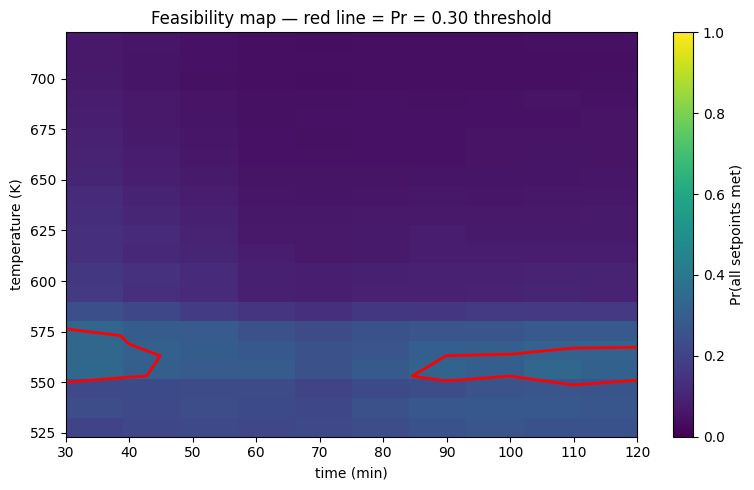

In [96]:
pivot = df_prob.pivot(index="temperature", columns="time",
                      values="pr_success_all")
plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[pivot.columns.min(), pivot.columns.max(),
                   pivot.index.min(), pivot.index.max()],
           cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Pr(all setpoints met)")
plt.contour(pivot.columns, pivot.index, pivot.values,
            levels=[1 - DELTA], colors="red", linewidths=2)
plt.xlabel("time (min)"); plt.ylabel("temperature (K)")
plt.title(f"Feasibility map — red line = Pr = {1-DELTA:.2f} threshold")
plt.tight_layout(); plt.show()

In [97]:
pivot

time,30,40,50,60,70,80,90,100,110,120
temperature,,,,,,,,,,
523,0.202599,0.211685,0.219641,0.214737,0.221906,0.236971,0.253827,0.263711,0.253533,0.251393
533,0.237366,0.219055,0.235751,0.223905,0.216034,0.247897,0.272735,0.276208,0.276067,0.265793
543,0.222205,0.224264,0.227428,0.233836,0.206504,0.225937,0.237336,0.253990,0.263118,0.259831
553,0.334564,0.304196,0.288918,0.289544,0.249232,0.283428,0.319849,0.300068,0.329326,0.310566
563,0.329633,0.306116,0.293629,0.276859,0.246601,0.262181,0.300343,0.302711,0.312932,0.316175
573,0.327840,0.295628,0.288305,0.247814,0.233782,0.252259,0.264367,0.268616,0.279198,0.278053
583,0.244901,0.217467,0.175923,0.149345,0.136759,0.160497,0.157180,0.168514,0.165590,0.166862
593,0.171516,0.134254,0.118640,0.089296,0.084083,0.090111,0.091798,0.096942,0.102969,0.099450
603,0.160974,0.141946,0.122627,0.089176,0.085878,0.086016,0.092343,0.093073,0.094875,0.095739


In [ ]:
df_prob.pr_success_iacs

,purity,iacs,grain_size,initial_diameter,tensile_strength,temperature,time,grain_size_mu,grain_size_sigma,grain_size_sigma2_epist,...,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,pr_success_iacs,pr_success_tensile_strength,pr_success_all
0,99.95,99,200.0,1.2,250.0,523,30,457.679499,209.439343,6594.808489,...,18.802371,108.445853,364.319336,1.0,232.148544,18.802371,0.0,0.230071,0.880595,0.202599
1,99.95,99,200.0,1.2,250.0,523,40,424.557393,199.749458,1143.030223,...,19.330748,135.390129,364.319336,1.0,231.124011,19.330748,0.0,0.245361,0.862752,0.211685
2,99.95,99,200.0,1.2,250.0,523,50,402.669714,197.898452,130.979196,...,20.206089,181.670803,364.319336,1.0,232.516513,20.206089,0.0,0.253208,0.867434,0.219641
3,99.95,99,200.0,1.2,250.0,523,60,405.637144,198.538744,479.997813,...,21.453522,251.165626,364.319336,1.0,231.218039,21.453522,0.0,0.256044,0.838674,0.214737
4,99.95,99,200.0,1.2,250.0,523,70,430.196986,202.765249,2812.116460,...,22.971588,341.351706,364.319336,1.0,229.362960,22.971588,0.0,0.277257,0.800360,0.221906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,99.95,99,200.0,1.2,250.0,723,80,691.287181,202.323853,2566.263857,...,20.250201,184.057304,364.319336,1.0,176.780695,20.250201,0.0,0.822119,0.050457,0.041481
206,99.95,99,200.0,1.2,250.0,723,90,716.750349,210.166980,7014.617957,...,20.265264,184.873432,364.319336,1.0,176.793076,20.265264,0.0,0.801020,0.050647,0.040569
207,99.95,99,200.0,1.2,250.0,723,100,754.206307,246.166883,29602.725184,...,20.261984,184.695644,364.319336,1.0,177.033390,20.261984,0.0,0.818992,0.051867,0.042478
208,99.95,99,200.0,1.2,250.0,723,110,784.172843,270.947130,47221.988155,...,20.248125,183.944848,364.319336,1.0,177.529549,20.248125,0.0,0.808822,0.054398,0.043998


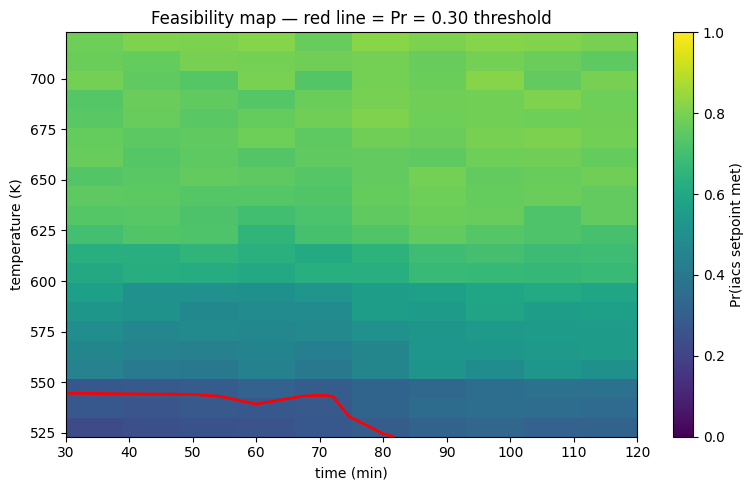

In [94]:
pivot = df_prob.pivot(index="temperature", columns="time",
                      values="pr_success_iacs")
plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[pivot.columns.min(), pivot.columns.max(),
                   pivot.index.min(), pivot.index.max()],
           cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Pr(iacs setpoint met)")
plt.contour(pivot.columns, pivot.index, pivot.values,
            levels=[1 - DELTA], colors="red", linewidths=2)
plt.xlabel("time (min)"); plt.ylabel("temperature (K)")
plt.title(f"Feasibility map — red line = Pr = {1-DELTA:.2f} threshold")
plt.tight_layout(); plt.show()

In [95]:
pivot

time,30,40,50,60,70,80,90,100,110,120
temperature,,,,,,,,,,
523,0.230071,0.245361,0.253208,0.256044,0.277257,0.296201,0.317533,0.330071,0.316121,0.316822
533,0.277165,0.262001,0.280164,0.277067,0.280722,0.322263,0.354863,0.359536,0.357626,0.347689
543,0.273600,0.284547,0.289226,0.314549,0.294335,0.321686,0.338177,0.361616,0.371627,0.371253
553,0.443114,0.417944,0.403852,0.439334,0.404267,0.458711,0.518191,0.485279,0.526806,0.502965
563,0.459575,0.444767,0.435234,0.452136,0.430896,0.456855,0.523889,0.526860,0.537601,0.548873
573,0.490065,0.463702,0.478147,0.463607,0.469876,0.505067,0.529984,0.536688,0.547897,0.550143
583,0.529997,0.510650,0.466030,0.482635,0.480500,0.560108,0.549434,0.583529,0.559366,0.566009
593,0.565877,0.504975,0.507791,0.503397,0.521229,0.555118,0.566087,0.590001,0.612680,0.592740
603,0.601621,0.623221,0.620925,0.605082,0.632499,0.628995,0.675592,0.671022,0.666619,0.672412


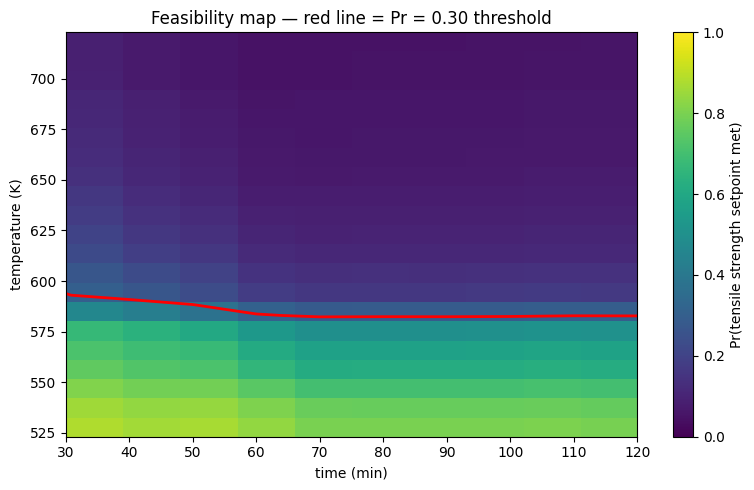

In [98]:
pivot = df_prob.pivot(index="temperature", columns="time",
                      values="pr_success_tensile_strength")
plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[pivot.columns.min(), pivot.columns.max(),
                   pivot.index.min(), pivot.index.max()],
           cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Pr(tensile strength setpoint met)")
plt.contour(pivot.columns, pivot.index, pivot.values,
            levels=[1 - DELTA], colors="red", linewidths=2)
plt.xlabel("time (min)"); plt.ylabel("temperature (K)")
plt.title(f"Feasibility map — red line = Pr = {1-DELTA:.2f} threshold")
plt.tight_layout(); plt.show()

In [99]:
pivot

time,30,40,50,60,70,80,90,100,110,120
temperature,,,,,,,,,,
523,0.880595,0.862752,0.867434,0.838674,0.800360,0.800035,0.799374,0.798953,0.802013,0.793483
533,0.856405,0.836085,0.841474,0.808124,0.769566,0.769240,0.768565,0.768236,0.771944,0.764456
543,0.812151,0.788143,0.786335,0.743401,0.701594,0.702351,0.701811,0.702375,0.708017,0.699875
553,0.755029,0.727839,0.715405,0.659052,0.616503,0.617878,0.617242,0.618340,0.625138,0.617469
563,0.717257,0.688262,0.674646,0.612336,0.572297,0.573883,0.573296,0.574556,0.582090,0.576044
573,0.668973,0.637538,0.602964,0.534534,0.497539,0.499456,0.498820,0.500507,0.509581,0.505419
583,0.462081,0.425862,0.377493,0.309436,0.284618,0.286546,0.286076,0.288785,0.296032,0.294804
593,0.303098,0.265863,0.233639,0.177387,0.161316,0.162328,0.162163,0.164308,0.168063,0.167781
603,0.267566,0.227761,0.197491,0.147378,0.135775,0.136752,0.136684,0.138704,0.142323,0.142382


# 7. Cost functions + risk-aware value

Operational cost (lower T, lower t = cheaper) and a physics budget proxy (T*t),
both normalised. Plus a one-sided 95% lower confidence bound on IACS so that, among
equally-cheap cells, the controller can prefer the one whose guarantee is robust.

In [83]:
df_cost = pev.add_cost_function(
    pev.add_cost_function_physics(df_feasible),
    operational_limits=OPERATIONAL_LIMITS,
)
# LCB per constrained target — looped over MIN_SETPOINTS instead of
# hardcoding names (same pattern as the scripts).
for short in MIN_SETPOINTS:
    df_cost = pev.add_risk_adjusted_value(df_cost, short, kappa=KAPPA)

df_cost[["temperature", "time", "cost", "cost_phys"]
        + [f"{t}_mu" for t in MIN_SETPOINTS]
        + [f"{t}_lcb" for t in MIN_SETPOINTS]
        + ["pr_success_all"]].sort_values("cost").head()


,temperature,time,cost,cost_phys,iacs_mu,tensile_strength_mu,iacs_lcb,tensile_strength_lcb,pr_success_all
30,553,30,0.150000,0.000000,101.292259,222.357776,98.340883,192.913191,0.334564
40,563,30,0.200000,0.005886,101.373816,220.432997,98.354762,190.570631,0.329633
50,573,30,0.250000,0.011772,101.510611,217.949550,98.603085,188.030499,0.327840
31,553,40,0.261111,0.108495,101.168337,221.131548,98.059275,190.929195,0.304196
41,563,40,0.311111,0.116343,101.300988,219.148115,98.305736,188.494813,0.306116


# 8. Select operating points

In [84]:
selected_low = pev.select_lowest_by_features(df_cost, SELECTION_SPEC_LOW)
selected_high = pev.select_highest_by_features(df_cost, SELECTION_SPEC_HIGH)
selected = {**selected_low, **selected_high}

for label, sub in selected.items():
    if len(sub):
        r = sub.iloc[0]
        print(f"{label:20s} -> T={r['temperature']:.0f}K t={r['time']:.0f}min "
              f"| iacs_mu={r['iacs_mu']:.2f} (+/-{r['iacs_sigma']:.2f}) "
              f"| Pr_all={r['pr_success_all']:.3f}")

lowest_time          -> T=553K t=30min | iacs_mu=101.29 (+/-1.79) | Pr_all=0.335
lowest_temperature   -> T=553K t=30min | iacs_mu=101.29 (+/-1.79) | Pr_all=0.335
lowest_cost          -> T=553K t=30min | iacs_mu=101.29 (+/-1.79) | Pr_all=0.335
lowest_cost_phys     -> T=553K t=30min | iacs_mu=101.29 (+/-1.79) | Pr_all=0.335
safest_iacs          -> T=563K t=120min | iacs_mu=101.74 (+/-1.61) | Pr_all=0.316
safest_combined      -> T=553K t=30min | iacs_mu=101.29 (+/-1.79) | Pr_all=0.335


In [85]:
# The "best for production" pick: cheapest cell that is also safe.
# (df_cost already passed the delta gate, so any of these is feasible.)
selected["lowest_cost"]

,purity,iacs,grain_size,initial_diameter,tensile_strength,temperature,time,grain_size_mu,grain_size_sigma,grain_size_sigma2_epist,...,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,pr_success_iacs,pr_success_tensile_strength,pr_success_all,cost_phys,cost,iacs_lcb,tensile_strength_lcb
0,99.95,99,200.0,1.2,250.0,553,30,564.568208,224.48999,15574.676744,...,222.357776,17.899444,0.0,0.443114,0.755029,0.334564,0.0,0.15,98.340883,192.913191


# 9. Inspect specific (T, t) pairs

Same targeted inspection the deterministic notebook offered, now with full
distribution + probability columns.

In [86]:
df_pairs = pev.filter_by_temperature_time_pairs(
    df_prob, temperatures=[573, 623, 673], times=[30, 60, 90],
)
df_pairs["temperature_C"] = df_pairs["temperature"] - 273
df_pairs[["temperature_C", "time", "iacs_mu", "iacs_sigma", "pr_success_iacs",
          "tensile_strength_mu", "tensile_strength_sigma", "pr_success_tensile_strength", "pr_success_all"]]

,temperature_C,time,iacs_mu,iacs_sigma,pr_success_iacs,tensile_strength_mu,tensile_strength_sigma,pr_success_tensile_strength,pr_success_all
50,300,30,101.510611,1.767493,0.490065,217.949550,18.187873,0.668973,0.327840
53,300,60,101.400062,1.892900,0.463607,211.674918,19.324966,0.534534,0.247814
56,300,90,101.679642,1.702753,0.529984,209.938584,20.767757,0.498820,0.264367
100,350,30,102.574472,1.788995,0.699641,195.322961,17.396008,0.199418,0.139521
103,350,60,102.455053,1.942679,0.655770,186.420305,18.626786,0.102774,0.067396
106,350,90,102.749876,1.623434,0.759379,185.238682,19.160644,0.098126,0.074515
150,400,30,102.915781,1.744714,0.764053,190.126903,16.824429,0.118761,0.090739
153,400,60,102.889467,1.643322,0.779108,181.238400,18.761817,0.062640,0.048803
156,400,90,102.913991,1.697112,0.772740,180.380380,19.349699,0.062915,0.048617


# 10. Export selections

In [87]:
IDENTIFIER = "downstream_propagation_pilot"
output_dir = Path(varv.PATHS.data_enriched) / "mbc_annealing_downstream"

# Shared export (same method the script calls): lean stakeholder layout,
# explicit column order built from the validated setpoint targets,
# saved to <output_dir>/<IDENTIFIER>/mbc_ann_unc.csv.
out_path = pev.export_selections(
    selected, output_dir, IDENTIFIER, targets=targets,
)
print(f"Exported to: {out_path}")


2026-07-17 09:03:27,470 | INFO | src.metrics.ProbabilisticEvaluation | Exported 6 selections to ..\..\data\enriched\mbc_annealing_downstream\downstream_propagation_pilot\mbc_ann_unc.csv


Exported to: ..\..\data\enriched\mbc_annealing_downstream\downstream_propagation_pilot\mbc_ann_unc.csv
